In [51]:
import pandas as pd

metric_paths = [
    '/data/all_checkpoints/PP_mistral7b_string+graph_gnn_freeze_0111/lightning_logs/version_2/metrics.csv',
    '/data/all_checkpoints/PP_mistral7b_string+graph_0111/lightning_logs/version_1/metrics.csv',
    '/data/all_checkpoints/PP_mistral7b_modality_random_0111/lightning_logs/version_1/metrics.csv',
    '/data/all_checkpoints/PP_mistral7b_string+graph_llava_projector_0111/lightning_logs/version_0/metrics.csv'
    ]
metrics = [pd.read_csv(metric_path) for metric_path in metric_paths]

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

def draw_line_plot(
        ax, df, column, label, xlabel='Val Epochs'):
    y = df[column].dropna()
    x = y.index
    ax.plot(x, y, label=label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(column)
    ax.legend()
    return ax

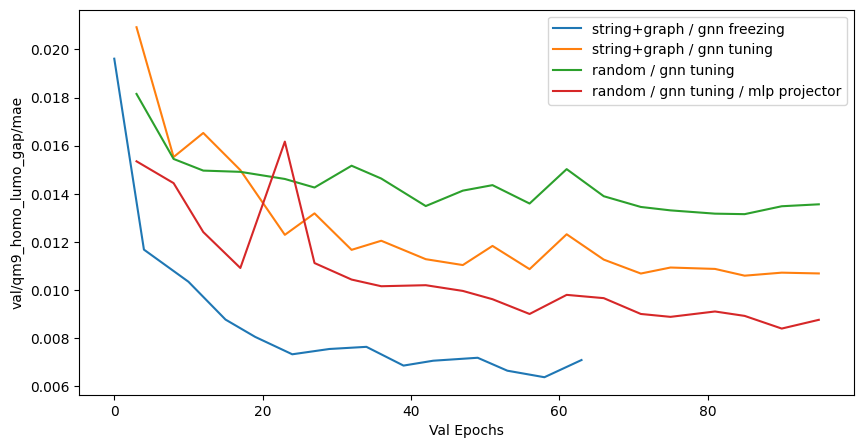

In [53]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)

column = 'val/qm9_homo_lumo_gap/mae'
labels = [
    'string+graph / gnn freezing',
    'string+graph / gnn tuning',
    'random / gnn tuning',
    'random / gnn tuning / mlp projector'
]

for i in range(len(metrics)):
    draw_line_plot(
        ax, metrics[i], column, label=labels[i]
    )